# YogAI - Master Pose Classifier Experiment
**Comparative ML Study: Logistic Regression vs SVC vs KNN vs XGBoost**

This notebook trains and benchmarks the **Master Pose Classifier** which discriminates
between three yoga poses: **Mountain**, **Plank**, and **Warrior2**.

This model sits upstream of all per-pose error classifiers - its prediction determines
which downstream error model runs next.

> **Class imbalance note**: The dataset is heavily imbalanced (~75% mountain,
> ~12% plank, ~13% warrior2). All classifiers are configured with `class_weight='balanced'`
> where supported, and XGBoost uses per-class `sample_weight` scaling. Both train/test
> splits use stratified group-aware splitting to preserve class ratios.
>
> **Plank data split note**: Plank rows with `source_id == 'plank'` are used for training
> and rows with `source_id == 'plank_test'` are reserved exclusively for testing.

All artifacts (pipeline, label encoder, class map, metadata) are saved to
the working directory for direct use during real-video inference.

### Notebook Structure
1. Environment setup & imports  
2. Configuration - Master Pose Classifier  
3. Data loading & validation  
4. Plank-aware train/test split (source_id-based hard split)  
5. Exploratory checks (class balance, feature stats, correlation)  
6. Class imbalance diagnostics & weighting strategy  
7. Experiment loop - all 4 models  
8. Results & benchmark table  
9. Visualizations (confusion matrices, latency, ROC-AUC, feature importance)  
10. Artifact verification  
11. Inference smoke-test

## 1. Environment Setup

In [1]:
# Install dependencies if running for the first time
# Comment out after first run
import subprocess, sys

packages = ["scikit-learn", "xgboost", "pandas", "numpy", "matplotlib",
            "seaborn", "joblib", "pyyaml", "imbalanced-learn"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All dependencies ready.")

All dependencies ready.


In [2]:
import sys
import json
import time
import math
import warnings
import logging
from pathlib import Path
from collections import defaultdict

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, StratifiedGroupKFold,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
)
from xgboost import XGBClassifier

# Add src/ to path so we can import project modules
NOTEBOOK_DIR = Path(".").resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[2]
SRC_DIR      = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

print(f"Working directory : {NOTEBOOK_DIR}")
print(f"src/ on path      : {SRC_DIR.exists()}")

Working directory : D:\YogAi_Models_Refactor\src\models\training
src/ on path      : True


## 2. Configuration — Master Pose Classifier

In [3]:
#  Pose identity 
POSE_NAME = "master_pose"

#  Master feature CSV path ─
# Single CSV containing engineered features for all three poses.
# Update these paths if your directory layout differs.
CSV_PATH = Path("../../../data/processed/engineered_features/master_pose/master_pose_features.csv")

#  Feature columns (must match CSV headers exactly) 
FEATURE_COLUMNS = [
    # Joint angles
    "left_elbow_angle",
    "right_elbow_angle",
    "left_knee_angle",
    "right_knee_angle",
    "left_hip_angle",
    "right_hip_angle",
    # Spatial distances
    "stance_width_normalized",
    "wrist_span_normalized",
    # Alignment offsets — key discriminators
    "torso_incline_angle",    # near-0 = upright (mountain/warrior2), large = plank
    "leg_incline_angle",
    "left_arm_elevation",
    "right_arm_elevation",
    "left_hip_line_deviation",
    "right_hip_line_deviation",
]

LABEL_COLUMN     = "label"
SOURCE_ID_COL    = "source_id"
FRAME_NUMBER_COL = "frame_number"

#  Plank-specific source_id split 
# Rows where source_id == PLANK_TRAIN_SOURCE_ID go to train only.
# Rows where source_id == PLANK_TEST_SOURCE_ID  go to test  only.
PLANK_TRAIN_SOURCE_ID = "plank"
PLANK_TEST_SOURCE_ID  = "plank_test"

#  Cross-validation settings ─
CV_CONFIG = {
    "n_splits"   : 5,
    "random_seed": 42,
    "scoring"    : "f1_macro",    # macro is stricter than weighted on imbalanced data
    "n_jobs"     : -1,
}

#  Hyperparameter grids ─
HYPERPARAMETER_GRIDS = {
    "logistic_regression": {
        "classifier__C"       : [0.01, 0.1, 1.0, 10.0, 100.0],
        "classifier__penalty" : ["l2"],
        "classifier__solver"  : ["lbfgs"],
        "classifier__max_iter": [2000],
        # class_weight is fixed to 'balanced' inside build_pipeline
    },
    "svc": {
        "classifier__C"     : [0.1, 1.0, 10.0, 100.0],
        "classifier__kernel": ["rbf", "linear"],
        "classifier__gamma" : ["scale", "auto"],
        # class_weight is fixed to 'balanced' inside build_pipeline
    },
    "knn": {
        "classifier__n_neighbors": [3, 5, 7, 11, 15],
        "classifier__weights"    : ["uniform", "distance"],
        "classifier__metric"     : ["euclidean", "manhattan"],
    },
    "xgboost": {
        "classifier__n_estimators"    : [100, 200, 300],
        "classifier__max_depth"       : [3, 5, 7],
        "classifier__learning_rate"   : [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample"       : [0.7, 0.8, 1.0],
        "classifier__colsample_bytree": [0.7, 0.8, 1.0],
        "classifier__min_child_weight": [1, 3, 5],
    },
}

XGBOOST_RANDOM_SEARCH_ITER = 40   # more iterations because grid is large
LATENCY_WARMUP_CALLS       = 10
LATENCY_TRIAL_CALLS        = 500

print("Configuration loaded.")
print(f"Pose        : {POSE_NAME}")
print(f"Features    : {FEATURE_COLUMNS}")
print(f"CV scoring  : {CV_CONFIG['scoring']} (macro — strict for imbalanced classes)")

Configuration loaded.
Pose        : master_pose
Features    : ['left_elbow_angle', 'right_elbow_angle', 'left_knee_angle', 'right_knee_angle', 'left_hip_angle', 'right_hip_angle', 'stance_width_normalized', 'wrist_span_normalized', 'torso_incline_angle', 'leg_incline_angle', 'left_arm_elevation', 'right_arm_elevation', 'left_hip_line_deviation', 'right_hip_line_deviation']
CV scoring  : f1_macro (macro — strict for imbalanced classes)


In [4]:
#  Output folder structure 
NOTEBOOK_DIR = Path(".").resolve()
OUTPUT_ROOT  = NOTEBOOK_DIR.parent / "saved_files" / f"{POSE_NAME}_files"

DIR_MODELS   = OUTPUT_ROOT / "models"
DIR_METADATA = OUTPUT_ROOT / "metadata"
DIR_RESULTS  = OUTPUT_ROOT / "results"
DIR_IMAGES   = OUTPUT_ROOT / "images"

for folder in [DIR_MODELS, DIR_METADATA, DIR_RESULTS, DIR_IMAGES]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Output root : {OUTPUT_ROOT}")
print(f"  models/   : {DIR_MODELS}")
print(f"  metadata/ : {DIR_METADATA}")
print(f"  results/  : {DIR_RESULTS}")
print(f"  images/   : {DIR_IMAGES}")

Output root : D:\YogAi_Models_Refactor\src\models\saved_files\master_pose_files
  models/   : D:\YogAi_Models_Refactor\src\models\saved_files\master_pose_files\models
  metadata/ : D:\YogAi_Models_Refactor\src\models\saved_files\master_pose_files\metadata
  results/  : D:\YogAi_Models_Refactor\src\models\saved_files\master_pose_files\results
  images/   : D:\YogAi_Models_Refactor\src\models\saved_files\master_pose_files\images


## 3. Data Loading & Validation

The unified pose features CSV is loaded directly. The `source_id` column
is preserved to enable group-aware CV splits.

In [5]:
#  Validate CSV path exists ─
assert CSV_PATH.exists(), (
    f"CSV not found at '{CSV_PATH}'.\n"
    f"Update CSV_PATH in the Configuration cell above."
)
print("CSV path found.")

CSV path found.


In [6]:
#  Load feature CSV ─
# The master classifier label is the pose name (mountain / plank / warrior2)
# which is stored in the 'label' column of the CSV.

df = pd.read_csv(CSV_PATH)
print(f"Dataset raw shape: {df.shape}")

# Ensure label and source_id columns exist
for col in [LABEL_COLUMN, SOURCE_ID_COL]:
    if col not in df.columns:
        raise ValueError(f"Required column '{col}' not found in the CSV.")

df.head()

Dataset raw shape: (42177, 18)


C:\Users\Acer\AppData\Local\Temp\ipykernel_18368\1453294923.py:5: DtypeWarning: Columns (0: frame_number, 1: left_elbow_angle, 2: right_elbow_angle, 3: left_knee_angle, 4: right_knee_angle, 5: left_hip_angle, 6: right_hip_angle, 7: stance_width_normalized, 8: wrist_span_normalized, 9: torso_incline_angle, 10: leg_incline_angle, 11: left_arm_elevation, 12: right_arm_elevation, 13: left_hip_line_deviation, 14: right_hip_line_deviation) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


,source_id,label,original_label,frame_number,left_elbow_angle,right_elbow_angle,left_knee_angle,right_knee_angle,left_hip_angle,right_hip_angle,stance_width_normalized,wrist_span_normalized,torso_incline_angle,leg_incline_angle,left_arm_elevation,right_arm_elevation,left_hip_line_deviation,right_hip_line_deviation
0,arms_not_dropped_1.mp4,mountain,arms_not_dropped,8,161.124111,175.226233,179.148941,179.368642,174.218988,175.163667,0.452677,2.938331,1.204063,0.45449,1.174914,1.28544,0.112843,0.084349
1,arms_not_dropped_1.mp4,mountain,arms_not_dropped,16,163.11477,172.802697,179.103689,179.076271,173.608214,175.340629,0.445744,2.994912,1.23932,0.316907,1.208298,1.284494,0.11702,0.080502
2,arms_not_dropped_1.mp4,mountain,arms_not_dropped,24,163.004291,174.046362,178.438234,179.380734,173.029125,175.289211,0.497913,3.008735,1.269206,0.373647,1.197254,1.286033,0.123644,0.085891
3,arms_not_dropped_1.mp4,mountain,arms_not_dropped,32,161.741118,174.612082,178.031316,179.221913,172.623974,175.379962,0.487715,3.017435,1.394262,0.282553,1.199085,1.28169,0.127138,0.08134
4,arms_not_dropped_1.mp4,mountain,arms_not_dropped,40,162.506598,174.661557,176.367109,179.375284,172.482093,175.271155,0.48178,3.023162,1.35646,0.7048,1.210721,1.27831,0.114849,0.085792


In [7]:
#  Validate required columns ─
required_cols = FEATURE_COLUMNS + [LABEL_COLUMN, SOURCE_ID_COL]
missing_cols  = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(
        f"Missing columns in merged DataFrame: {missing_cols}\n"
        f"Available: {list(df.columns)}"
    )

print("All required columns present.")
print(f"\nColumn dtypes:")
print(df[required_cols].dtypes)

All required columns present.

Column dtypes:
left_elbow_angle            object
right_elbow_angle           object
left_knee_angle             object
right_knee_angle            object
left_hip_angle              object
right_hip_angle             object
stance_width_normalized     object
wrist_span_normalized       object
torso_incline_angle         object
leg_incline_angle           object
left_arm_elevation          object
right_arm_elevation         object
left_hip_line_deviation     object
right_hip_line_deviation    object
label                          str
source_id                      str
dtype: object


In [8]:
#  Null check & clean 
null_counts = df[required_cols].isnull().sum()
null_counts = null_counts[null_counts > 0]

if not null_counts.empty:
    print("WARNING: Null values detected:")
    print(null_counts)
    print("\nDropping rows with nulls...")
    df = df.dropna(subset=required_cols)
    print(f"Shape after dropping nulls: {df.shape}")
else:
    print("No null values. Dataset is clean.")

No null values. Dataset is clean.


In [9]:
#  Stance width outlier removal (same guard as warrior2 notebook) ─
# before = len(df)
# df = df[df["stance_width_normalized"] < 5.0]
# print(f"Stance-width outlier removal: {before - len(df)} rows dropped → {len(df)} remaining")

# Stance width outlier removal (same guard as warrior2 notebook) ─
before = len(df)
df["stance_width_normalized"] = pd.to_numeric(df["stance_width_normalized"], errors='coerce')
df = df[df["stance_width_normalized"] < 5.0]
print(f"Stance-width outlier removal: {before - len(df)} rows dropped → {len(df)} remaining")


Stance-width outlier removal: 137 rows dropped → 42040 remaining


In [10]:
#  Encode labels ─
label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(df[LABEL_COLUMN].str.lower().str.strip())

class_map = {idx: cls for idx, cls in enumerate(label_encoder.classes_)}
print("Label encoding:")
for k, v in class_map.items():
    count = (y_encoded == k).sum()
    print(f"  {k} -> '{v}'  ({count} samples, {count/len(y_encoded)*100:.1f}%)")

print(f"\nClass imbalance ratio (max/min): "
      f"{max(np.bincount(y_encoded)) / min(np.bincount(y_encoded)):.2f}x")

Label encoding:
  0 -> 'chair'  (2894 samples, 6.9%)
  1 -> 'mountain'  (4627 samples, 11.0%)
  2 -> 'plank'  (29161 samples, 69.4%)
  3 -> 'warrior2'  (5358 samples, 12.7%)

Class imbalance ratio (max/min): 10.08x


In [11]:
#  Extract X, y, groups ─
X      = df[FEATURE_COLUMNS].values
y      = y_encoded
groups = df[SOURCE_ID_COL].values

print(f"Dataset summary")
print(f"  Samples          : {len(X)}")
print(f"  Features         : {X.shape[1]}")
print(f"  Classes          : {len(class_map)}")
print(f"  Unique source_ids: {len(np.unique(groups))}")

Dataset summary
  Samples          : 42040
  Features         : 14
  Classes          : 4
  Unique source_ids: 402


## 4. Plank-Aware Train / Test Split

Plank data uses a **hard source_id-based split** — rows with
`source_id == 'plank'` are assigned to training and rows with
`source_id == 'plank_test'` are assigned to test exclusively.

For mountain and warrior2 a **StratifiedGroupKFold** outer split
(80% train / 20% test) is applied. Groups (source_ids) are never
split across train and test, preventing temporal data leakage.

In [12]:
seed = CV_CONFIG["random_seed"]
rng  = np.random.default_rng(seed)

plank_encoded = label_encoder.transform(["plank"])[0]

#  1. Hard-split plank rows by source_id ─
plank_train_mask = (groups == PLANK_TRAIN_SOURCE_ID)
plank_test_mask  = (groups == PLANK_TEST_SOURCE_ID)

if not plank_train_mask.any():
    raise ValueError(
        f"No plank rows found with source_id='{PLANK_TRAIN_SOURCE_ID}'. "
        f"Check the CSV or PLANK_TRAIN_SOURCE_ID value."
    )
if not plank_test_mask.any():
    raise ValueError(
        f"No plank rows found with source_id='{PLANK_TEST_SOURCE_ID}'. "
        f"Check the CSV or PLANK_TEST_SOURCE_ID value."
    )

print(f"Plank train rows (source_id='{PLANK_TRAIN_SOURCE_ID}'): {plank_train_mask.sum()}")
print(f"Plank test  rows (source_id='{PLANK_TEST_SOURCE_ID}') : {plank_test_mask.sum()}")

#  2. Separate non-plank data for group-aware outer split 
other_mask = ~plank_train_mask & ~plank_test_mask
X_other      = X[other_mask]
y_other      = y[other_mask]
groups_other = groups[other_mask]

outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
train_idx_other, test_idx_other = next(
    outer_cv.split(X_other, y_other, groups=groups_other)
)

#  3. Merge plank hard-split with non-plank group-split ─
X_train = np.vstack([X[plank_train_mask], X_other[train_idx_other]])
y_train = np.concatenate([y[plank_train_mask], y_other[train_idx_other]])


# groups_train = np.concatenate([groups[plank_train_mask], groups_other[train_idx_other]])

# override plank group IDs with a single sentinel so CV never splits them
plank_group_labels = np.full(plank_train_mask.sum(), fill_value=PLANK_TRAIN_SOURCE_ID)
groups_train = np.concatenate([plank_group_labels, groups_other[train_idx_other]])

X_test  = np.vstack([X[plank_test_mask], X_other[test_idx_other]])
y_test  = np.concatenate([y[plank_test_mask], y_other[test_idx_other]])

train_sources = set(np.unique(groups_train))
test_sources  = set(np.unique(np.concatenate([groups[plank_test_mask], groups_other[test_idx_other]])))

# Verify no group leakage
leaked = train_sources & test_sources
assert not leaked, f"Source_id leakage detected: {leaked}"

print(f"\nTrain : {len(X_train)} samples | {len(train_sources)} unique source_ids")
print(f"Test  : {len(X_test)} samples  | {len(test_sources)} unique source_ids")
print("\nTrain class distribution:")
for k, v in class_map.items():
    count = (y_train == k).sum()
    print(f"  {v}: {count} ({count/len(y_train)*100:.1f}%)")
print("\nTest class distribution:")
for k, v in class_map.items():
    count = (y_test == k).sum()
    print(f"  {v}: {count} ({count/len(y_test)*100:.1f}%)")

Plank train rows (source_id='plank'): 28452
Plank test  rows (source_id='plank_test') : 709

Train : 38793 samples | 324 unique source_ids
Test  : 3247 samples  | 78 unique source_ids

Train class distribution:
  chair: 2329 (6.0%)
  mountain: 3713 (9.6%)
  plank: 28452 (73.3%)
  warrior2: 4299 (11.1%)

Test class distribution:
  chair: 565 (17.4%)
  mountain: 914 (28.1%)
  plank: 709 (21.8%)
  warrior2: 1059 (32.6%)


## 5. Exploratory Checks

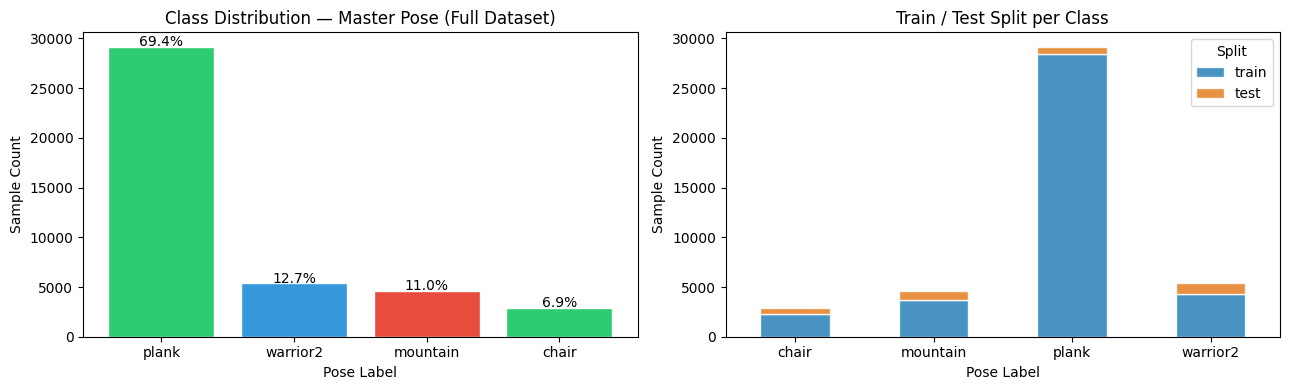

In [13]:
#  Class distribution — full dataset ─
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_strings = label_encoder.inverse_transform(y)
class_counts  = pd.Series(label_strings).value_counts()

bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=["#2ecc71", "#3498db", "#e74c3c"], edgecolor="white")
axes[0].set_title("Class Distribution — Master Pose (Full Dataset)", fontsize=12)
axes[0].set_ylabel("Sample Count")
axes[0].set_xlabel("Pose Label")
for bar in bars:
    pct = bar.get_height() / len(y) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{pct:.1f}%", ha="center", fontsize=10)

# Train vs test breakdown stacked bar
split_data = {}
for k, v in class_map.items():
    split_data[v] = {
        "train": int((y_train == k).sum()),
        "test" : int((y_test  == k).sum()),
    }
df_split = pd.DataFrame(split_data).T
df_split.plot(kind="bar", stacked=True, ax=axes[1],
              color=["#2980b9", "#e67e22"], edgecolor="white", alpha=0.85)
axes[1].set_title("Train / Test Split per Class", fontsize=12)
axes[1].set_xlabel("Pose Label")
axes[1].set_ylabel("Sample Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Split")

plt.tight_layout()
plt.savefig(DIR_IMAGES / f"{POSE_NAME}_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
#  Feature statistics 
feature_df = pd.DataFrame(X, columns=FEATURE_COLUMNS)
feature_df.describe().round(4)

,left_elbow_angle,right_elbow_angle,left_knee_angle,right_knee_angle,left_hip_angle,right_hip_angle,stance_width_normalized,wrist_span_normalized,torso_incline_angle,leg_incline_angle,left_arm_elevation,right_arm_elevation,left_hip_line_deviation,right_hip_line_deviation
count,42040,42040,42040,42040,42040,42040,42040.0000,42040,42040,42040,42040,42040,42040,42040
unique,42011,42011,42011,42011,42011,42011,42011.0000,42011,42011,42011,42011,42011,42011,42011
top,170.46540315594493,163.31429641405464,178.936493833088,103.39288094427909,124.56193001354984,82.74336781681208,3.3664,4.243098847297757,9.952200066119996,16.19527116415839,0.00575383474642109,0.01969007085301392,0.6919413789256563,0.6937769211574646
freq,3,3,3,3,3,3,3.0000,3,3,3,3,3,3,3


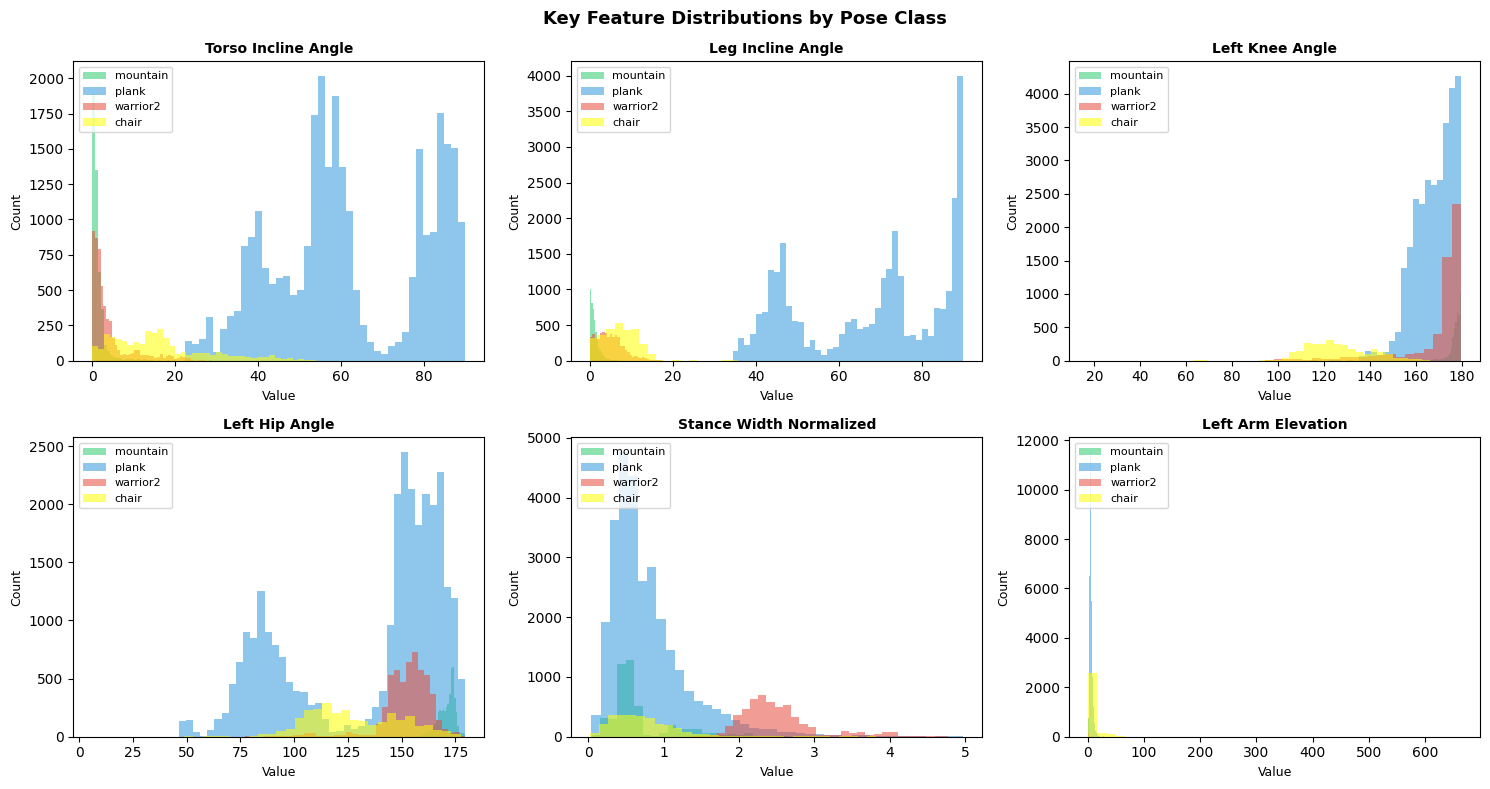

In [17]:

import os
# Setup and Data Preparation 
highlight_features = [
    "torso_incline_angle",
    "leg_incline_angle",
    "left_knee_angle",
    "left_hip_angle",
    "stance_width_normalized",
    "left_arm_elevation",
]

# Map your class names to the exact hex colors shown in image_058c4a.png
palette = {
    "mountain": "#2ecc71",   # Green
    "plank": "#3498db",      # Blue
    "warrior2": "#e74c3c",    # Red/Coral
    "chair": "yellow"
}

# Create the EDA DataFrame from your features (X) and labels (y)
df_eda = pd.DataFrame(X, columns=FEATURE_COLUMNS)
df_eda[FEATURE_COLUMNS] = df_eda[FEATURE_COLUMNS].apply(pd.to_numeric, errors='coerce')
df_eda["pose"] = label_encoder.inverse_transform(y)

# Plotting Configuration 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()

# Loop through each highlighted feature and its corresponding subplot axis
for ax, feat in zip(axes_flat, highlight_features):
    # Plot each pose's distribution individually to mimic the original layered histogram style
    for pose_label, color in palette.items():
        vals = df_eda.loc[df_eda["pose"] == pose_label, feat].dropna()
        
        ax.hist(
            vals, 
            bins=40, 
            alpha=0.55, 
            label=pose_label, 
            color=color, 
            edgecolor="none"  # Removed invalid 'showfliers=False' argument
        )
        
    # Styling and formatting matching image_058c4a.png
    ax.set_title(feat.replace("_", " ").title(), fontsize=10, weight="bold")
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=8, loc="upper left")

# Global Layout & Saving 
plt.suptitle("Key Feature Distributions by Pose Class", fontsize=13, weight="bold")
plt.tight_layout()

# Save the figure to your designated images directory
os.makedirs(DIR_IMAGES, exist_ok=True)
plt.savefig(DIR_IMAGES / f"{POSE_NAME}_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

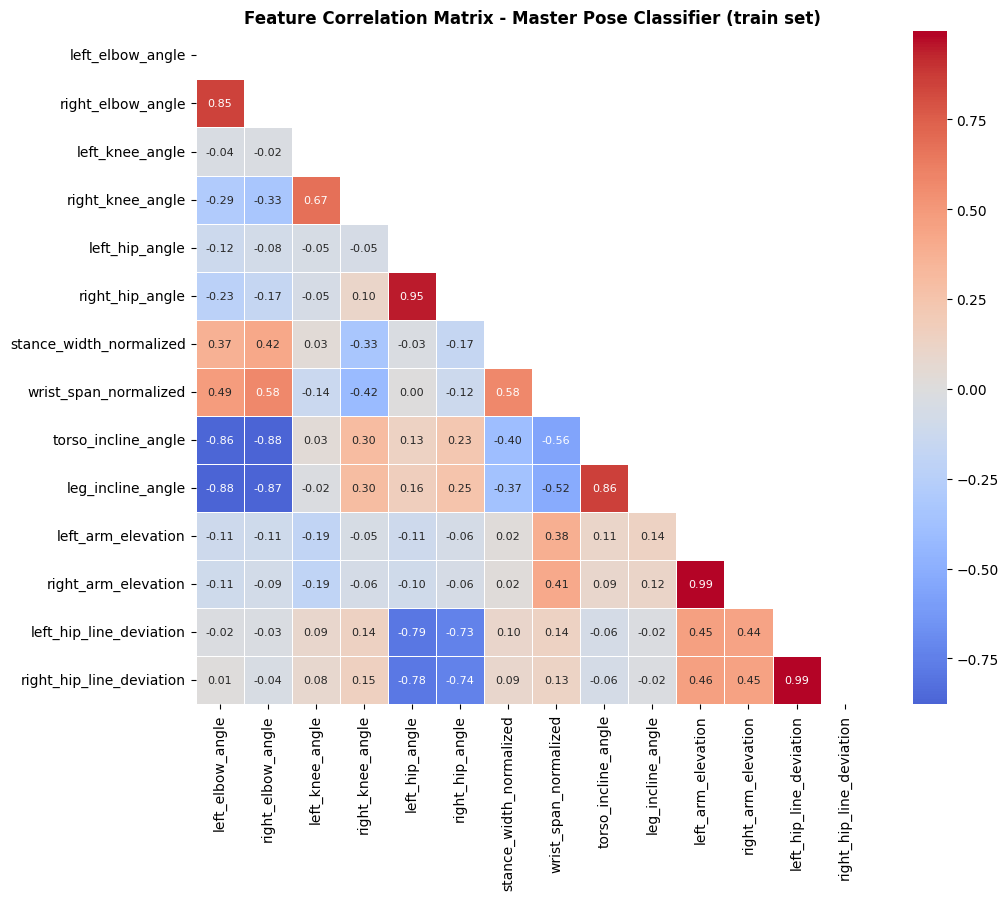

In [18]:
#  Feature correlation heatmap ─
fig, ax = plt.subplots(figsize=(11, 9))
corr = pd.DataFrame(X_train, columns=FEATURE_COLUMNS).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=ax,
    linewidths=0.5, square=True, annot_kws={"size": 8},
)
ax.set_title("Feature Correlation Matrix - Master Pose Classifier (train set)",
             fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig(DIR_IMAGES / f"{POSE_NAME}_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Class Imbalance Diagnostics & Weighting Strategy

With ~75% mountain / ~12% plank / ~13% warrior2, naive training will overfit to
mountain. Strategy:
- **LogisticRegression & SVC**: `class_weight='balanced'` (sklearn handles it natively)
- **XGBoost**: `sample_weight` passed as a fit parameter (inverse-frequency weighting)
- **KNN**: distance-weighted voting (`weights='distance'`) is included in the grid;
  KNN has no `class_weight` parameter but distance weighting partially compensates

In [19]:
train_counts     = np.bincount(y_train)
imbalance_ratio  = train_counts.max() / train_counts.min()

print(f"Train class counts : {dict(zip(class_map.values(), train_counts))}")
print(f"Imbalance ratio    : {imbalance_ratio:.2f}x")
print()

# Compute sample weights for XGBoost (inverse frequency)
sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train)

print("Sample weight stats per class (XGBoost):")
for k, v in class_map.items():
    mask = y_train == k
    print(f"  {v:<12}: mean weight = {sample_weights_train[mask].mean():.4f}")

if imbalance_ratio >= 3.0:
    print("\nAssessment: IMBALANCED — applying class_weight='balanced' (LR/SVC) "
          "and sample_weight (XGBoost). Scoring set to f1_macro.")
else:
    print("\nAssessment: MILDLY IMBALANCED — weighting applied as a precaution.")

Train class counts : {'chair': np.int64(2329), 'mountain': np.int64(3713), 'plank': np.int64(28452), 'warrior2': np.int64(4299)}
Imbalance ratio    : 12.22x

Sample weight stats per class (XGBoost):
  chair       : mean weight = 4.1641
  mountain    : mean weight = 2.6120
  plank       : mean weight = 0.3409
  warrior2    : mean weight = 2.2559

Assessment: IMBALANCED — applying class_weight='balanced' (LR/SVC) and sample_weight (XGBoost). Scoring set to f1_macro.


## 7. Experiment Helpers

In [20]:
def build_pipeline(model_name: str) -> Pipeline:
    """
    Return an unfitted sklearn Pipeline: StandardScaler -> estimator.
    LR and SVC have class_weight='balanced' baked in to handle the
    ~75/12/13 mountain/plank/warrior2 imbalance.
    """
    seed = CV_CONFIG["random_seed"]

    estimators = {
        "logistic_regression": LogisticRegression(
            random_state=seed, max_iter=2000,
            class_weight="balanced",     # ← imbalance compensation
        ),
        "svc": SVC(
            random_state=seed, probability=True,
            class_weight="balanced",     # ← imbalance compensation
        ),
        "knn": KNeighborsClassifier(n_neighbors=5),
        "xgboost": XGBClassifier(
            random_state=seed,
            verbosity=0,
            eval_metric="mlogloss",
            # sample_weight is passed at fit() time — not here
        ),
    }

    if model_name not in estimators:
        raise ValueError(f"Unknown model '{model_name}'. Choose from {list(estimators)}")

    return Pipeline([
        ("scaler"    , StandardScaler()),
        ("classifier", estimators[model_name]),
    ])


def check_knn_neighbor_cap(n_neighbors_grid: list, n_training_samples: int) -> None:
    ceiling   = math.floor(math.sqrt(n_training_samples))
    oversized = [k for k in n_neighbors_grid if k > ceiling]
    if oversized:
        warnings.warn(
            f"KNN grid has n_neighbors values {oversized} exceeding the "
            f"recommended ceiling floor(sqrt({n_training_samples})) = {ceiling}. "
            f"Consider trimming the grid.",
            UserWarning, stacklevel=2,
        )


def measure_inference_latency(
    pipeline, X_probe: np.ndarray,
    n_warmup: int = LATENCY_WARMUP_CALLS,
    n_trials: int = LATENCY_TRIAL_CALLS,
) -> dict:
    """Measure per-sample prediction latency with warmup."""
    for _ in range(n_warmup):
        pipeline.predict(X_probe)

    latencies_ms = np.empty(n_trials)
    for i in range(n_trials):
        t0 = time.perf_counter()
        pipeline.predict(X_probe)
        latencies_ms[i] = (time.perf_counter() - t0) * 1000.0

    return {
        "mean_ms"        : round(float(np.mean(latencies_ms)), 4),
        "std_ms"         : round(float(np.std(latencies_ms)), 4),
        "p95_ms"         : round(float(np.percentile(latencies_ms, 95)), 4),
        "p99_ms"         : round(float(np.percentile(latencies_ms, 99)), 4),
        "implied_max_fps": round(1000.0 / float(np.mean(latencies_ms)), 1),
    }


def load_results_from_disk(pose_name: str, experiment_tag: str,
                           models: list, DIR_METADATA: Path) -> list:
    """Load experiment results from saved metadata JSONs."""
    results = []
    for model_name in models:
        prefix    = f"{pose_name}_{experiment_tag}_{model_name}"
        meta_path = DIR_METADATA / f"{prefix}_metadata.json"
        if not meta_path.exists():
            print(f"[WARNING] Missing: {meta_path.name} — skipping")
            continue
        with open(meta_path) as f:
            results.append(json.load(f))
    print(f"Loaded {len(results)}/{len(models)} models for '{pose_name}' — '{experiment_tag}'")
    return results


print("Helper functions defined.")

Helper functions defined.


## 8. CV Fold Diagnostics

Verify that all classes appear in every fold before running the experiment loop.
Empty folds produce misleading CV scores and must be caught early.

In [21]:
#  StratifiedGroupKFold feasibility check
# Plank rows are kept in training for every fold via PlankAwareCVSplitter.
# Plank is evaluated exclusively on plank_test (X_test / y_test).

class PlankAwareCVSplitter:
    """
    Custom CV splitter that always assigns ALL plank training rows
    to the training set of every fold.  Only mountain and warrior2
    rows are rotated through validation.  Plank is never in the
    validation set, so XGBoost always sees all 3 classes in training.
    """
    def __init__(self, base_cv, plank_mask_train):
        self.base_cv          = base_cv
        self.plank_mask_train = plank_mask_train  # bool array over X_train

    def split(self, X, y, groups=None):
        plank_idx     = np.where(self.plank_mask_train)[0]
        non_plank_idx = np.where(~self.plank_mask_train)[0]

        X_np = X[non_plank_idx]
        y_np = y[non_plank_idx]
        g_np = groups[non_plank_idx] if groups is not None else None

        for tr_rel, val_rel in self.base_cv.split(X_np, y_np, g_np):
            tr_abs  = non_plank_idx[tr_rel]
            val_abs = non_plank_idx[val_rel]
            # Always prepend ALL plank rows to training
            tr_abs  = np.concatenate([plank_idx, tr_abs])
            yield tr_abs, val_abs

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.base_cv.get_n_splits()


PLANK_CLASS_NAME    = class_map[plank_encoded]
plank_mask_in_train = (y_train == plank_encoded)

n_unique_train_sources = len(np.unique(groups_train[~plank_mask_in_train]))
n_splits_actual        = min(CV_CONFIG["n_splits"], n_unique_train_sources)

print(f"Unique non-plank training source_ids : {n_unique_train_sources}")
print(f"CV n_splits                          : {n_splits_actual}")
print(f"Plank training rows (always in train): {plank_mask_in_train.sum()}")
print(f"Note: plank is evaluated via plank_test only.")
print()

_base_sgkf = StratifiedGroupKFold(n_splits=n_splits_actual)
_diag_cv   = PlankAwareCVSplitter(_base_sgkf, plank_mask_in_train)
fold_ok    = True

for fold_idx, (tr_idx, val_idx) in enumerate(
        _diag_cv.split(X_train, y_train, groups=groups_train)):
    val_labels   = y_train[val_idx]
    class_counts = {class_map[k]: int((val_labels == k).sum()) for k in sorted(class_map)}
    zeros  = [cls for cls, cnt in class_counts.items() if cnt == 0]
    status = "✓" if not zeros else f"✗  EMPTY CLASSES: {zeros}"
    print(f"  Fold {fold_idx}: {class_counts}  {status}")
    if zeros:
        fold_ok = False

print()
print("CLEAN — safe to proceed." if fold_ok else
      "WARNING: Some folds have empty classes. "
      "Consider reducing n_splits or collecting more minority-class data.")




Unique non-plank training source_ids : 323
CV n_splits                          : 5
Plank training rows (always in train): 28452
Note: plank is evaluated via plank_test only.

  Fold 0: {'chair': 466, 'mountain': 735, 'plank': 0, 'warrior2': 833}  ✗  EMPTY CLASSES: ['plank']
  Fold 1: {'chair': 466, 'mountain': 749, 'plank': 0, 'warrior2': 832}  ✗  EMPTY CLASSES: ['plank']
  Fold 2: {'chair': 466, 'mountain': 739, 'plank': 0, 'warrior2': 901}  ✗  EMPTY CLASSES: ['plank']
  Fold 3: {'chair': 465, 'mountain': 743, 'plank': 0, 'warrior2': 901}  ✗  EMPTY CLASSES: ['plank']
  Fold 4: {'chair': 466, 'mountain': 747, 'plank': 0, 'warrior2': 832}  ✗  EMPTY CLASSES: ['plank']



## 9. Experiment Loop — All 4 Models

In [22]:
assert seed is not None, "Global seed must be set before the experiment loop"

from sklearn.metrics import make_scorer, f1_score as sk_f1

def f1_macro_present_labels(y_true, y_pred):
    """Macro F1 over labels actually present in y_true only.
    Prevents plank (absent from CV validation) from zeroing out the macro avg."""
    labels = np.unique(y_true)
    return sk_f1(y_true, y_pred, labels=labels, average='macro', zero_division=0)

cv_scorer = make_scorer(f1_macro_present_labels)

cv_strategy = PlankAwareCVSplitter(
    base_cv          = StratifiedGroupKFold(n_splits=n_splits_actual),
    plank_mask_train = plank_mask_in_train,
)

print(f"CV strategy : PlankAwareCVSplitter wrapping StratifiedGroupKFold with {n_splits_actual} splits")
print(f"Scoring     : {CV_CONFIG['scoring']} (macro — penalises poor minority-class recall)")
print()

MODELS         = ["logistic_regression", "svc", "knn", "xgboost"]
experiment_tag = "master_3class"
all_results    = []
best_pipelines = {}
WEIGHTED_AVG_KEY = "weighted avg"

for model_name in MODELS:
    print(f"{'='*60}")
    print(f"  Running: {model_name.upper().replace('_', ' ')}")
    print(f"{'='*60}")

    try:
        pipeline   = build_pipeline(model_name)
        param_grid = HYPERPARAMETER_GRIDS[model_name]

        if model_name == "knn":
            min_fold_train = int(len(X_train) * (n_splits_actual - 1) / n_splits_actual)
            check_knn_neighbor_cap(param_grid["classifier__n_neighbors"], min_fold_train)

        #  Search strategy 
        if model_name == "xgboost":
            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=param_grid,
                n_iter=XGBOOST_RANDOM_SEARCH_ITER,
                # scoring=CV_CONFIG["scoring"],
                scoring=cv_scorer,
                
                cv=cv_strategy,
                n_jobs=CV_CONFIG["n_jobs"],
                random_state=seed,
                refit=True,
                verbose=0,
            )
        else:
            search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                # scoring=CV_CONFIG["scoring"],
                scoring=cv_scorer,

                cv=cv_strategy,
                n_jobs=CV_CONFIG["n_jobs"],
                refit=True,
                verbose=0,
            )

        #  Fit — XGBoost receives sample_weight to compensate imbalance 
        if model_name == "xgboost":
            search.fit(
                X_train, y_train,
                groups=groups_train,
                classifier__sample_weight=sample_weights_train,
            )
        else:
            search.fit(X_train, y_train, groups=groups_train)

        best_pipeline = search.best_estimator_
        best_pipelines[model_name] = best_pipeline

        #  Evaluate ─
        y_pred   = best_pipeline.predict(X_test)
        clf_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        clf_str  = classification_report(
            y_test, y_pred,
            target_names=list(class_map.values()),
            zero_division=0,
        )
        conf_mat = confusion_matrix(y_test, y_pred)

        X_probe = X_test[:50]
        latency = measure_inference_latency(best_pipeline, X_probe)

        #  Build result dict 
        result = {
            "model"                    : model_name,
            "best_cv_score"            : round(search.best_score_, 4),
            "test_f1_macro"            : round(clf_dict["macro avg"]["f1-score"], 4),
            "test_f1_weighted"         : round(clf_dict[WEIGHTED_AVG_KEY]["f1-score"], 4),
            "test_precision_weighted"  : round(clf_dict[WEIGHTED_AVG_KEY]["precision"], 4),
            "test_recall_weighted"     : round(clf_dict[WEIGHTED_AVG_KEY]["recall"], 4),
            "test_accuracy"            : round(clf_dict["accuracy"], 4),
            "best_params"              : search.best_params_,
            "classification_report_str": clf_str,
            "confusion_matrix"         : conf_mat,
            "confusion_matrix_list"    : conf_mat.tolist(),
            **latency,
        }

        # Per-class recall from report
        for k, v in class_map.items():
            result[f"recall_{v}"] = round(clf_dict.get(v, {}).get("recall", 0.0), 4)

        best_index = search.best_index_
        fold_scores = [
            round(search.cv_results_[f"split{i}_test_score"][best_index], 4)
            for i in range(n_splits_actual)
        ]
        result["cv_folds_scores"] = fold_scores

        # Feature importances
        clf_step = best_pipeline.named_steps["classifier"]
        if model_name == "xgboost":
            result["feature_importances"]     = clf_step.feature_importances_.tolist()
            result["has_feature_importances"] = True
        elif model_name == "logistic_regression":
            result["feature_importances"]     = np.mean(np.abs(clf_step.coef_), axis=0).tolist()
            result["has_feature_importances"] = True
        else:
            result["feature_importances"]     = None
            result["has_feature_importances"] = False

        all_results.append(result)

        #  Print summary 
        print(f"Best CV score  : {result['best_cv_score']}  (f1_macro)")
        print(f"Best params    : {search.best_params_}")
        print()
        print("Classification Report (test set):")
        print(clf_str)
        print(f"Latency  mean={latency['mean_ms']} ms | "
              f"p95={latency['p95_ms']} ms | "
              f"p99={latency['p99_ms']} ms | "
              f"implied FPS={latency['implied_max_fps']}")

        #  Save artifacts ─
        prefix = f"{POSE_NAME}_{experiment_tag}_{model_name}"

        joblib.dump(best_pipeline, DIR_MODELS / f"{prefix}_pipeline.joblib")
        joblib.dump(label_encoder, DIR_MODELS / f"{prefix}_label_encoder.joblib")

        with open(DIR_METADATA / f"{prefix}_class_map.json", "w") as f:
            json.dump({str(k): v for k, v in class_map.items()}, f, indent=2)

        metadata = {
            "pose"              : POSE_NAME,
            "experiment_tag"    : experiment_tag,
            "model"             : model_name,
            "feature_columns"   : FEATURE_COLUMNS,
            "n_features"        : len(FEATURE_COLUMNS),
            "best_params"       : search.best_params_,
            "best_cv_score"     : result["best_cv_score"],
            "cv_folds_scores"   : fold_scores,
            "test_f1_macro"     : result["test_f1_macro"],
            "test_f1_weighted"  : result["test_f1_weighted"],
            "test_accuracy"     : result["test_accuracy"],
            "per_class_recall"  : {v: result[f"recall_{v}"] for v in class_map.values()},
            "n_train"           : len(X_train),
            "n_test"            : len(X_test),
            "cv_config"         : CV_CONFIG,
            "class_map"         : {str(k): v for k, v in class_map.items()},
            "imbalance_strategy": "class_weight=balanced (LR/SVC), sample_weight (XGBoost)",
            "latency"           : latency,
            "confusion_matrix"  : conf_mat.tolist(),
            "classification_report": clf_str,
        }

        with open(DIR_METADATA / f"{prefix}_metadata.json", "w") as f:
            json.dump(metadata, f, indent=2)

        print(f"Artifacts saved  →  {OUTPUT_ROOT.name}/")
        print(f"  models/   {prefix}_pipeline.joblib")
        print(f"  models/   {prefix}_label_encoder.joblib")
        print(f"  metadata/ {prefix}_class_map.json")
        print(f"  metadata/ {prefix}_metadata.json")
        print()

    except Exception as e:
        print(f"[ERROR] {model_name} failed — skipping. Reason: {e}")
        import traceback; traceback.print_exc()
        continue

print("All Experiments Completed.")

CV strategy : PlankAwareCVSplitter wrapping StratifiedGroupKFold with 5 splits
Scoring     : f1_macro (macro — penalises poor minority-class recall)

  Running: LOGISTIC REGRESSION


d:\YogAi_Models_Refactor\venv_yogai\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best CV score  : 0.9989  (f1_macro)
Best params    : {'classifier__C': 10.0, 'classifier__max_iter': 2000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Classification Report (test set):
              precision    recall  f1-score   support

       chair       1.00      1.00      1.00       565
    mountain       1.00      1.00      1.00       914
       plank       1.00      1.00      1.00       709
    warrior2       1.00      1.00      1.00      1059

    accuracy                           1.00      3247
   macro avg       1.00      1.00      1.00      3247
weighted avg       1.00      1.00      1.00      3247

Latency  mean=0.1573 ms | p95=0.197 ms | p99=0.5323 ms | implied FPS=6357.0
Artifacts saved  →  master_pose_files/
  models/   master_pose_master_3class_logistic_regression_pipeline.joblib
  models/   master_pose_master_3class_logistic_regression_label_encoder.joblib
  metadata/ master_pose_master_3class_logistic_regression_class_map.json
  metadata/ master_pos

d:\YogAi_Models_Refactor\venv_yogai\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV score  : 0.9984  (f1_macro)
Best params    : {'classifier__subsample': 0.7, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 1, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.7}

Classification Report (test set):
              precision    recall  f1-score   support

       chair       1.00      1.00      1.00       565
    mountain       1.00      1.00      1.00       914
       plank       1.00      1.00      1.00       709
    warrior2       1.00      1.00      1.00      1059

    accuracy                           1.00      3247
   macro avg       1.00      1.00      1.00      3247
weighted avg       1.00      1.00      1.00      3247

Latency  mean=0.9607 ms | p95=1.2734 ms | p99=1.4238 ms | implied FPS=1040.9
Artifacts saved  →  master_pose_files/
  models/   master_pose_master_3class_xgboost_pipeline.joblib
  models/   master_pose_master_3class_xgboost_label_encoder.joblib
  metadata/ master_pose_master_3cl

## 10. Results & Benchmark Table

In [23]:
#  Flat benchmark table ─
benchmark_cols = [
    "model", "best_cv_score",
    "test_f1_macro", "test_f1_weighted",
    "test_precision_weighted", "test_recall_weighted", "test_accuracy",
    "recall_mountain", "recall_plank", "recall_warrior2",
    "mean_ms", "p95_ms", "p99_ms", "implied_max_fps",
]

results_df = pd.DataFrame(all_results)[benchmark_cols]
results_df = results_df.sort_values("test_f1_macro", ascending=False).reset_index(drop=True)

csv_path = DIR_RESULTS / f"{POSE_NAME}_{experiment_tag}_experiment_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"Results saved to {OUTPUT_ROOT.name}/results/{csv_path.name}")
print()
results_df

Results saved to master_pose_files/results/master_pose_master_3class_experiment_results.csv



,model,best_cv_score,test_f1_macro,test_f1_weighted,test_precision_weighted,test_recall_weighted,test_accuracy,recall_mountain,recall_plank,recall_warrior2,mean_ms,p95_ms,p99_ms,implied_max_fps
0,knn,0.9981,0.9996,0.9997,0.9997,0.9997,0.9997,0.0,0.0,0.0,8.2005,10.2150,11.5859,121.9
1,logistic_regression,0.9989,0.9989,0.9991,0.9991,0.9991,0.9991,0.0,0.0,0.0,0.1573,0.1970,0.5323,6357.0
2,xgboost,0.9984,0.9989,0.9991,0.9991,0.9991,0.9991,0.0,0.0,0.0,0.9607,1.2734,1.4238,1040.9
3,svc,0.9991,0.9985,0.9988,0.9988,0.9988,0.9988,0.0,0.0,0.0,0.8554,1.1217,1.4134,1169.0


## 11. Visualizations

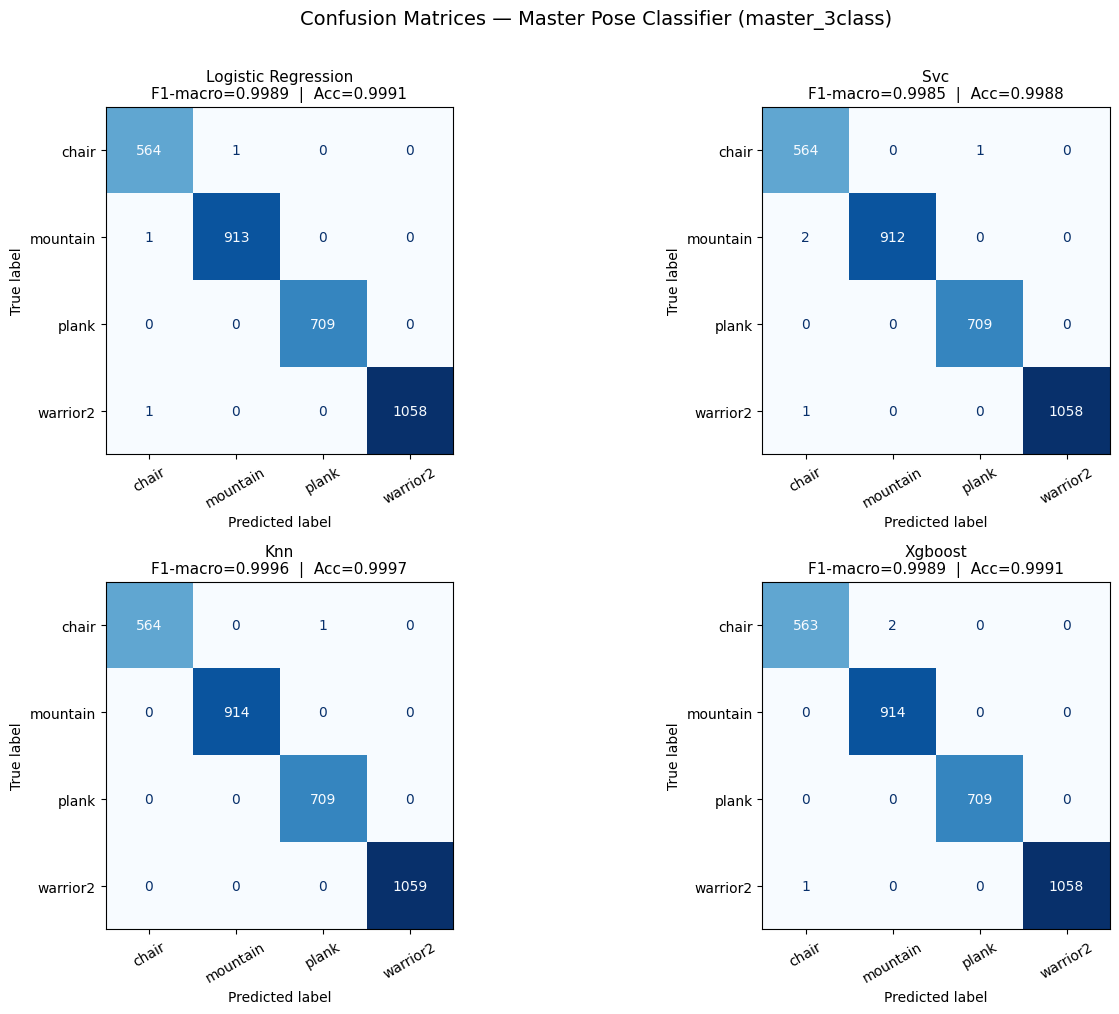

Saved → master_pose_files/images/master_pose_master_3class_confusion_matrices.png


In [24]:
#  Confusion matrices — all 4 models ─
fig, axes   = plt.subplots(2, 2, figsize=(14, 10))
axes        = axes.flatten()
class_names = list(class_map.values())

for i, result in enumerate(all_results):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=class_names,
    )
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(
        f"{result['model'].replace('_', ' ').title()}\n"
        f"F1-macro={result['test_f1_macro']:.4f}  |  "
        f"Acc={result['test_accuracy']:.4f}",
        fontsize=11,
    )
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle(
    f"Confusion Matrices — Master Pose Classifier ({experiment_tag})",
    fontsize=14, y=1.01,
)
plt.tight_layout()
img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_confusion_matrices.png"
plt.savefig(img_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_ROOT.name}/images/{img_path.name}")

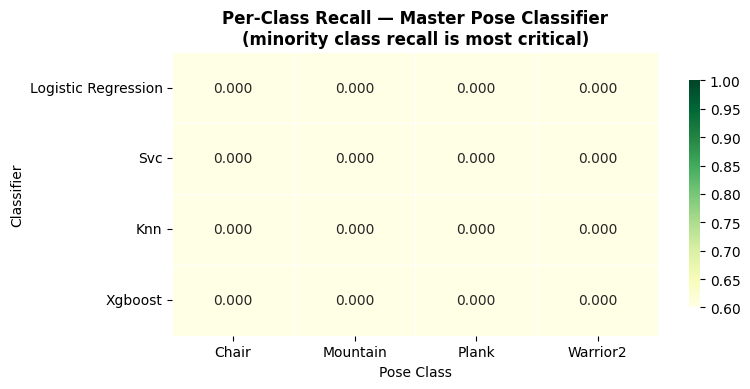

In [25]:
#  Per-class recall heatmap ─
# Minority class recall is the most critical metric for the master classifier.
# A missed plank or warrior2 prediction misdirects the entire downstream pipeline.

recall_data = {
    r["model"].replace("_", " ").title(): [
        r.get(f"recall_{v}", 0.0) for v in class_map.values()
    ]
    for r in all_results
}
df_recall = pd.DataFrame(
    recall_data,
    index=[v.title() for v in class_map.values()]
).T

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    df_recall.astype(float), ax=ax,
    annot=True, fmt=".3f", cmap="YlGn",
    vmin=0.60, vmax=1.00,
    linewidths=0.5, cbar_kws={"shrink": 0.8},
)
ax.set_title("Per-Class Recall — Master Pose Classifier\n"
             "(minority class recall is most critical)",
             fontsize=12, weight="bold")
ax.set_xlabel("Pose Class", fontsize=10)
ax.set_ylabel("Classifier", fontsize=10)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_recall_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

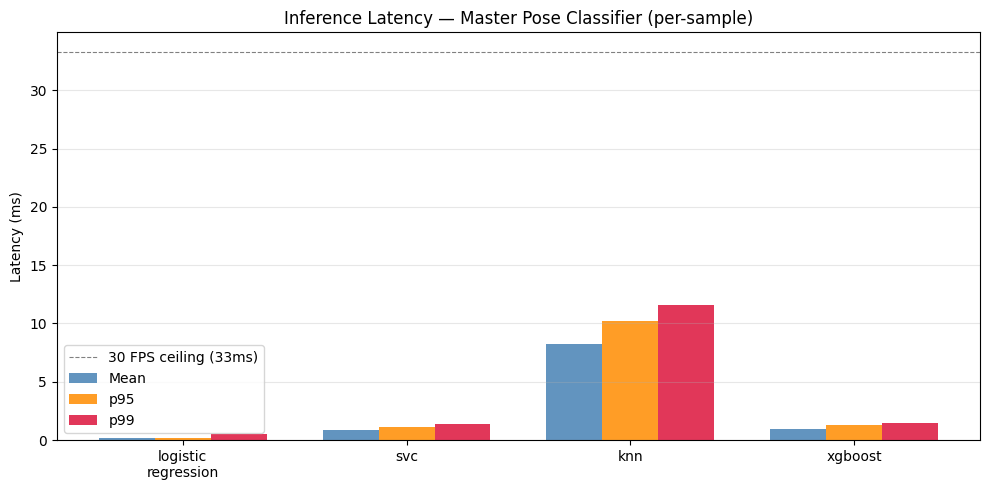

Saved → master_pose_files/images/master_pose_master_3class_latency_comparison.png


In [26]:
#  Latency comparison bar chart ─
fig, ax = plt.subplots(figsize=(10, 5))

model_labels = [r["model"].replace("_", "\n") for r in all_results]
mean_vals    = [r["mean_ms"] for r in all_results]
p95_vals     = [r["p95_ms"]  for r in all_results]
p99_vals     = [r["p99_ms"]  for r in all_results]

x     = np.arange(len(model_labels))
width = 0.25

ax.bar(x - width, mean_vals, width, label="Mean",  color="steelblue",  alpha=0.85)
ax.bar(x,         p95_vals,  width, label="p95",   color="darkorange", alpha=0.85)
ax.bar(x + width, p99_vals,  width, label="p99",   color="crimson",    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel("Latency (ms)")
ax.set_title("Inference Latency — Master Pose Classifier (per-sample)")
ax.axhline(y=33.3, color="gray", linestyle="--", linewidth=0.8, label="30 FPS ceiling (33ms)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_latency_comparison.png"
plt.savefig(img_path, dpi=150)
plt.show()
print(f"Saved → {OUTPUT_ROOT.name}/images/{img_path.name}")

C:\Users\Acer\AppData\Local\Temp\ipykernel_18368\4277283218.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


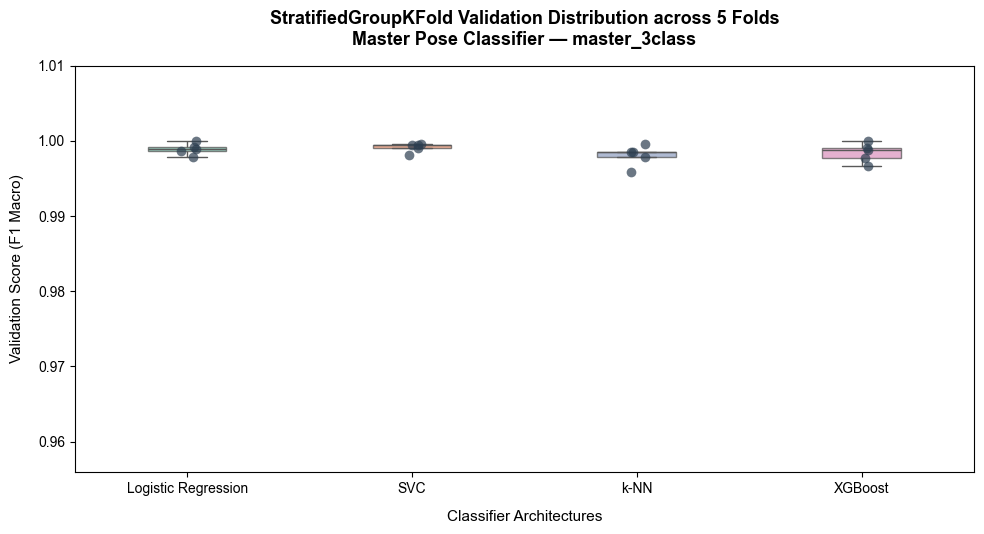

Saved → master_pose_files/images/master_pose_master_3class_groupkfold_variance.png


In [27]:
#  GroupKFold stability box plot 
cv_box_data = {r["model"]: r["cv_folds_scores"] for r in all_results}
df_cv_box   = pd.DataFrame(cv_box_data)

formal_names = {
    "logistic_regression": "Logistic Regression",
    "svc": "SVC",
    "knn": "k-NN",
    "xgboost": "XGBoost",
}
df_cv_box.columns = [formal_names.get(col, col) for col in df_cv_box.columns]
df_cv_melted = df_cv_box.melt(var_name="Model", value_name="Cross-Val Score")

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.set_theme(style="whitegrid")
sns.boxplot(
    data=df_cv_melted, x="Model", y="Cross-Val Score",
    palette="Set2", width=0.35, showfliers=False, ax=ax,
    boxprops=dict(alpha=0.75)
)
sns.stripplot(
    data=df_cv_melted, x="Model", y="Cross-Val Score",
    color="#2c3e50", alpha=0.7, size=7, jitter=0.05, ax=ax
)

scoring_name = CV_CONFIG["scoring"].replace("_", " ").title()
ax.set_title(
    f"StratifiedGroupKFold Validation Distribution across {n_splits_actual} Folds\n"
    f"Master Pose Classifier — {experiment_tag}",
    fontsize=13, pad=15, weight="bold"
)
ax.set_ylabel(f"Validation Score ({scoring_name})", fontsize=11, labelpad=10)
ax.set_xlabel("Classifier Architectures", fontsize=11, labelpad=10)
min_val = df_cv_melted["Cross-Val Score"].min()
ax.set_ylim(max(0.0, min_val - 0.04), 1.01)
plt.tight_layout()
box_img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_groupkfold_variance.png"
plt.savefig(box_img_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_ROOT.name}/images/{box_img_path.name}")

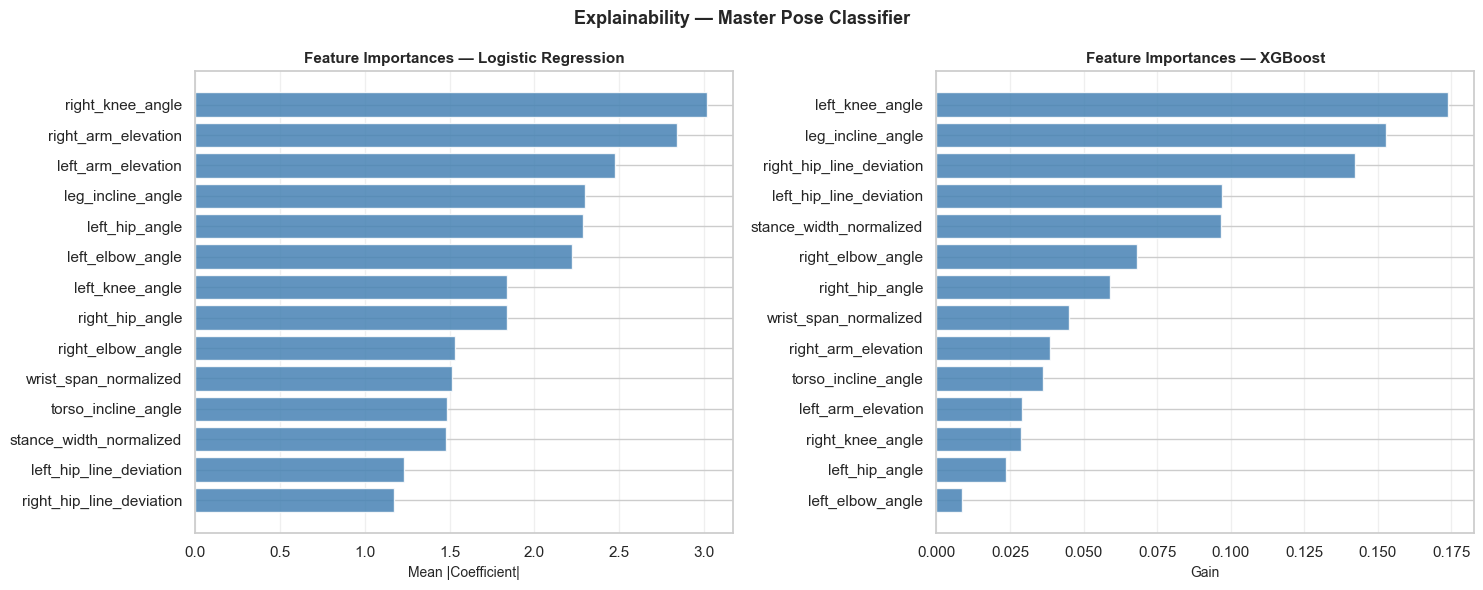

In [28]:
#  Feature importances — LR & XGBoost 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
importance_models = [r for r in all_results if r["has_feature_importances"]]

for ax, result in zip(axes, importance_models):
    importances = np.array(result["feature_importances"])
    sorted_idx  = np.argsort(importances)

    ax.barh(
        [FEATURE_COLUMNS[i] for i in sorted_idx],
        importances[sorted_idx],
        color="steelblue", alpha=0.85
    )
    formal = {"logistic_regression": "Logistic Regression", "xgboost": "XGBoost"}
    ax.set_title(
        f"Feature Importances — {formal[result['model']]}",
        fontsize=11, weight="bold"
    )
    ax.set_xlabel(
        "Mean |Coefficient|" if result["model"] == "logistic_regression" else "Gain",
        fontsize=10
    )
    ax.grid(axis="x", alpha=0.3)

plt.suptitle(
    "Explainability — Master Pose Classifier",
    fontsize=13, weight="bold"
)
plt.tight_layout()
plt.savefig(
    DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_feature_importances.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

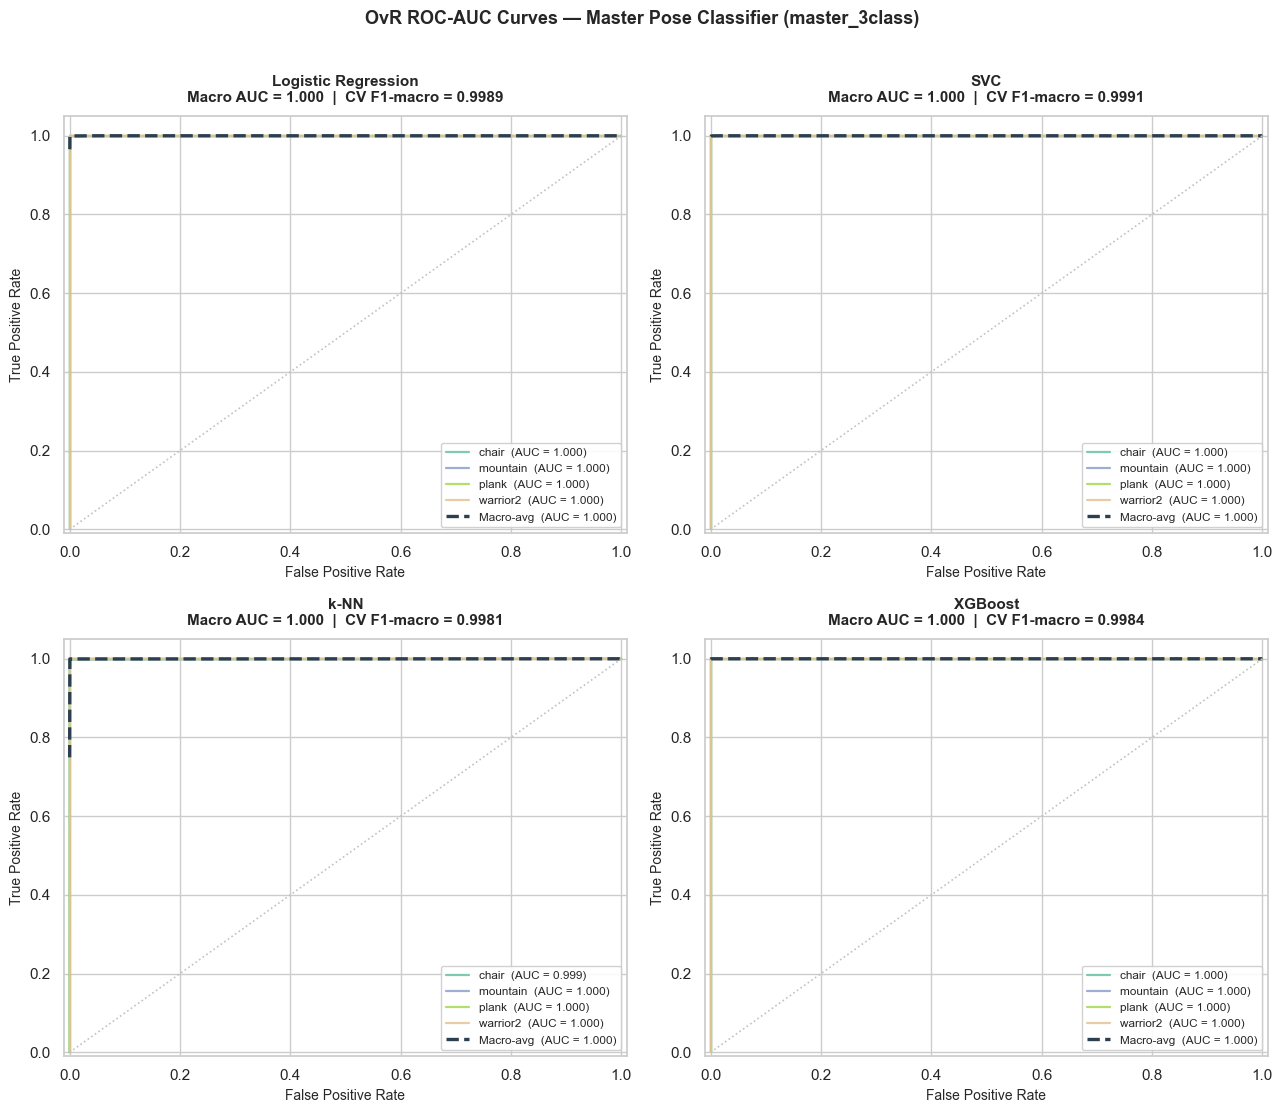

Saved ROC-AUC plot → master_pose_files/images/master_pose_master_3class_roc_auc_curves.png


In [29]:
#  One-vs-Rest ROC-AUC curves ─
classes      = sorted(class_map.keys())
class_labels = [class_map[c] for c in classes]
n_classes    = len(classes)
y_bin        = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
sns.set_theme(style="whitegrid")
axes_flat         = axes.flatten()
per_class_palette = plt.cm.Set2(np.linspace(0, 0.85, n_classes))

for ax_idx, result in enumerate(all_results):
    model_name    = result["model"]
    best_pipeline = best_pipelines[model_name]
    ax            = axes_flat[ax_idx]

    if hasattr(best_pipeline, "predict_proba"):
        y_score = best_pipeline.predict_proba(X_test)
    else:
        from sklearn.preprocessing import MinMaxScaler
        y_score = MinMaxScaler().fit_transform(
            best_pipeline.decision_function(X_test)
        )

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i]        = auc(fpr[i], tpr[i])

    all_fpr   = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr  = np.mean([np.interp(all_fpr, fpr[i], tpr[i]) for i in range(n_classes)], axis=0)
    macro_auc = auc(all_fpr, mean_tpr)

    for i, label in enumerate(class_labels):
        ax.plot(fpr[i], tpr[i], color=per_class_palette[i], lw=1.6, alpha=0.85,
                label=f"{label}  (AUC = {roc_auc[i]:.3f})")

    ax.plot(all_fpr, mean_tpr, color="#2c3e50", lw=2.4, linestyle="--",
            label=f"Macro-avg  (AUC = {macro_auc:.3f})")
    ax.plot([0, 1], [0, 1], color="#bdc3c7", lw=1.2, linestyle=":")

    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.set_title(
        f"{formal_names.get(model_name, model_name)}\n"
        f"Macro AUC = {macro_auc:.3f}  |  CV F1-macro = {result['best_cv_score']:.4f}",
        fontsize=11, weight="bold", pad=10,
    )
    ax.legend(fontsize=8.5, loc="lower right", framealpha=0.9)

fig.suptitle(
    f"OvR ROC-AUC Curves — Master Pose Classifier ({experiment_tag})",
    fontsize=13, weight="bold", y=1.01,
)
plt.tight_layout()
roc_img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_roc_auc_curves.png"
plt.savefig(roc_img_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved ROC-AUC plot → {OUTPUT_ROOT.name}/images/{roc_img_path.name}")

## 12. Artifact Verification

In [30]:
#  Confirm all expected artifacts were written 
expected_files = []
for model_name in MODELS:
    prefix = f"{POSE_NAME}_{experiment_tag}_{model_name}"
    expected_files += [
        DIR_MODELS   / f"{prefix}_pipeline.joblib",
        DIR_MODELS   / f"{prefix}_label_encoder.joblib",
        DIR_METADATA / f"{prefix}_class_map.json",
        DIR_METADATA / f"{prefix}_metadata.json",
    ]

expected_files += [
    DIR_RESULTS / f"{POSE_NAME}_{experiment_tag}_experiment_results.csv",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_confusion_matrices.png",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_latency_comparison.png",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_roc_auc_curves.png",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_recall_heatmap.png",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_feature_importances.png",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_groupkfold_variance.png",
    DIR_IMAGES  / f"{POSE_NAME}_class_distribution.png",
    DIR_IMAGES  / f"{POSE_NAME}_feature_distributions.png",
    DIR_IMAGES  / f"{POSE_NAME}_correlation_heatmap.png",
]

all_ok = True
for fpath in expected_files:
    exists = fpath.exists()
    status = "OK" if exists else "MISSING"
    folder = fpath.parent.name
    if not exists:
        all_ok = False
    print(f"  [{status}]  {folder}/{fpath.name}")

print()
print("All artifacts present." if all_ok else "WARNING: Some artifacts are missing.")

  [OK]  models/master_pose_master_3class_logistic_regression_pipeline.joblib
  [OK]  models/master_pose_master_3class_logistic_regression_label_encoder.joblib
  [OK]  metadata/master_pose_master_3class_logistic_regression_class_map.json
  [OK]  metadata/master_pose_master_3class_logistic_regression_metadata.json
  [OK]  models/master_pose_master_3class_svc_pipeline.joblib
  [OK]  models/master_pose_master_3class_svc_label_encoder.joblib
  [OK]  metadata/master_pose_master_3class_svc_class_map.json
  [OK]  metadata/master_pose_master_3class_svc_metadata.json
  [OK]  models/master_pose_master_3class_knn_pipeline.joblib
  [OK]  models/master_pose_master_3class_knn_label_encoder.joblib
  [OK]  metadata/master_pose_master_3class_knn_class_map.json
  [OK]  metadata/master_pose_master_3class_knn_metadata.json
  [OK]  models/master_pose_master_3class_xgboost_pipeline.joblib
  [OK]  models/master_pose_master_3class_xgboost_label_encoder.joblib
  [OK]  metadata/master_pose_master_3class_xgboost_

## 13. Inference Smoke-Test

Loads the **best-performing model** by F1-macro and runs a prediction on a
single test sample, replicating the exact round-trip the real-video inference
script will execute:

`raw features → load pipeline → predict → decode label`

In [32]:
#  Pick best model by test F1-macro 
best_model_name = results_df.iloc[0]["model"]
prefix = f"{POSE_NAME}_{experiment_tag}_{best_model_name}"

print(f"Best model : {best_model_name} "
      f"(F1-macro={results_df.iloc[0]['test_f1_macro']:.4f})")
print()

#  Load artifacts from disk ─
loaded_pipeline = joblib.load(DIR_MODELS / f"{prefix}_pipeline.joblib")
loaded_encoder  = joblib.load(DIR_MODELS / f"{prefix}_label_encoder.joblib")

with open(DIR_METADATA / f"{prefix}_class_map.json") as f:
    loaded_class_map = json.load(f)

with open(DIR_METADATA / f"{prefix}_metadata.json") as f:
    loaded_metadata = json.load(f)

print("Loaded artifacts:")
print(f"  Pipeline       : {loaded_pipeline}")
print(f"  Label encoder  : classes = {list(loaded_encoder.classes_)}")
print(f"  Feature columns: {loaded_metadata['feature_columns']}")
print()

#  Predict on one sample from each class ─
print("Per-class smoke-test (one sample per pose):")
for pose_label, pose_idx in zip(class_map.values(), class_map.keys()):
    mask = y_test == pose_idx
    if not mask.any():
        print(f"  [{pose_label}] - no test sample available")
        continue
    sample  = X_test[mask][0:1]
    raw_pred = loaded_pipeline.predict(sample)
    decoded  = loaded_encoder.inverse_transform(raw_pred)[0]
    status   = "✓" if decoded == pose_label else f"✗  (got '{decoded}')"
    print(f"  [{pose_label}] → predicted '{decoded}'  {status}")

print()
print("Smoke-test complete.")

Best model : knn (F1-macro=0.9996)

Loaded artifacts:
  Pipeline       : Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=3,
                                      weights='distance'))])
  Label encoder  : classes = ['chair', 'mountain', 'plank', 'warrior2']
  Feature columns: ['left_elbow_angle', 'right_elbow_angle', 'left_knee_angle', 'right_knee_angle', 'left_hip_angle', 'right_hip_angle', 'stance_width_normalized', 'wrist_span_normalized', 'torso_incline_angle', 'leg_incline_angle', 'left_arm_elevation', 'right_arm_elevation', 'left_hip_line_deviation', 'right_hip_line_deviation']

Per-class smoke-test (one sample per pose):
  [chair] → predicted 'chair'  ✓
  [mountain] → predicted 'mountain'  ✓
  [plank] → predicted 'plank'  ✓
  [warrior2] → predicted 'warrior2'  ✓

Smoke-test complete.
